In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [4]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Mean:")
print(df[numeric_columns].mean())

print("\nMedian:")
print(df[numeric_columns].median())

print("\nStandard Deviation:")
print(df[numeric_columns].std())


Mean:
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

Median:
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

Standard Deviation:
PassengerId    257.353842
Survived         0.486592
Pclass           0.836071
Age             14.526497
SibSp            1.102743
Parch            0.806057
Fare            49.693429
dtype: float64


In [7]:
df.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


In [8]:
print("Sex:")
print(df['Sex'].unique())

print("\nEmbarked:")
print(df['Embarked'].unique())

print("\nPclass:")
print(df['Pclass'].unique())

Sex:
['male' 'female']

Embarked:
['S' 'C' 'Q' nan]

Pclass:
[3 1 2]


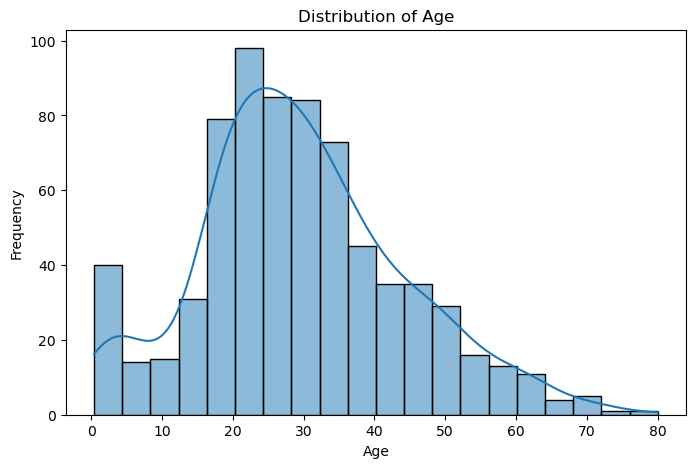

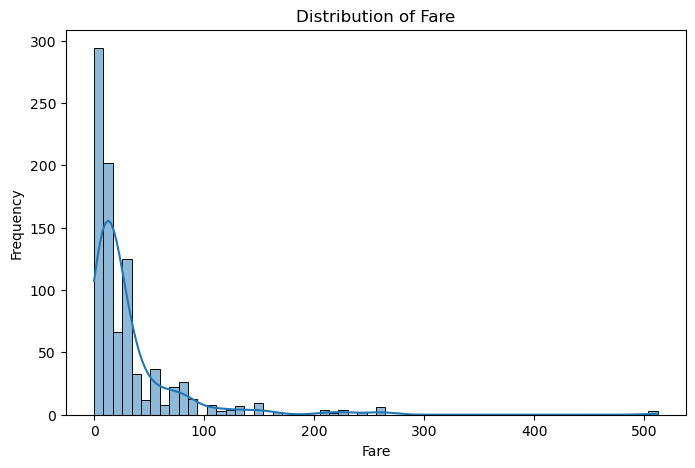

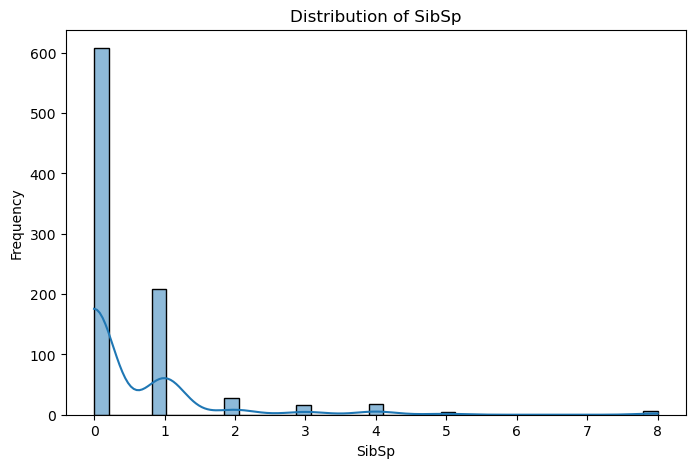

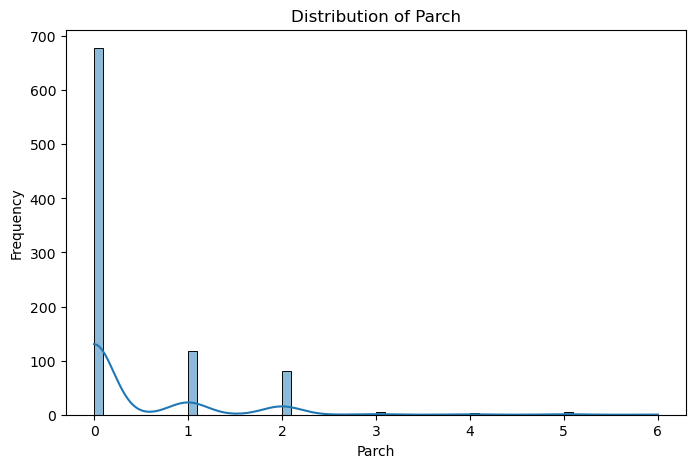

In [9]:
numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']

for column in numeric_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

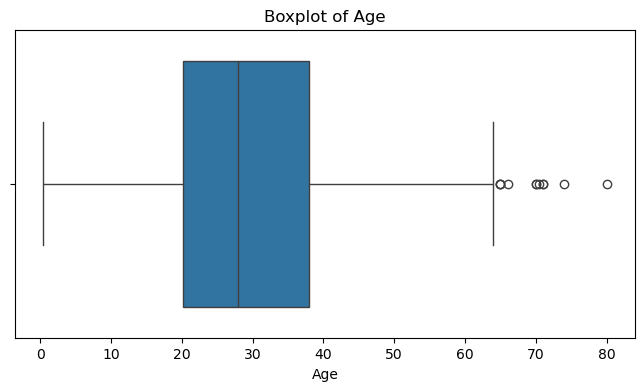

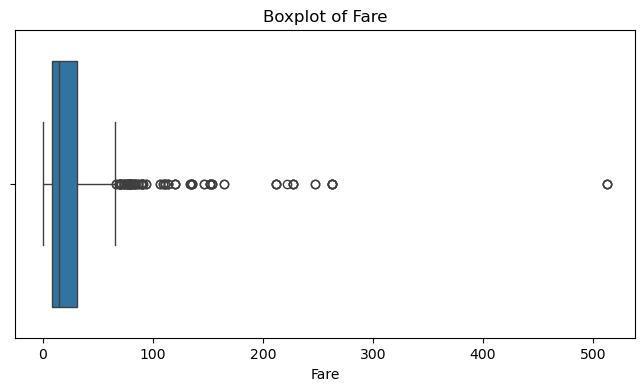

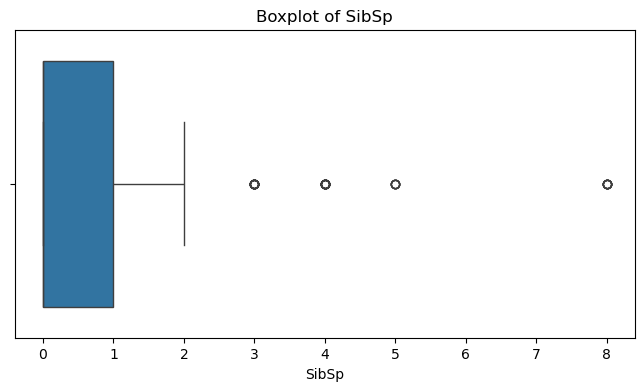

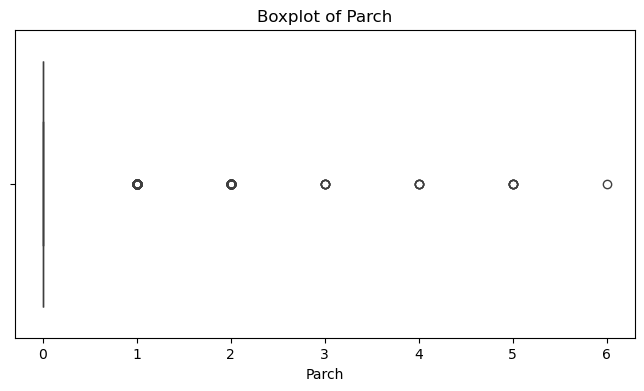

In [10]:
for column in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    plt.show()

In [11]:
print("Survival Count:")
print(df['Survived'].value_counts())

print("\nSurvival Percentage:")
print(df['Survived'].value_counts(normalize=True) * 100)

Survival Count:
Survived
0    549
1    342
Name: count, dtype: int64

Survival Percentage:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


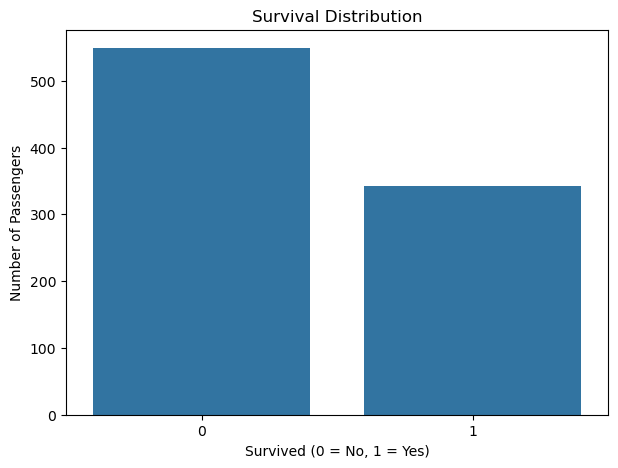

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Survived')
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

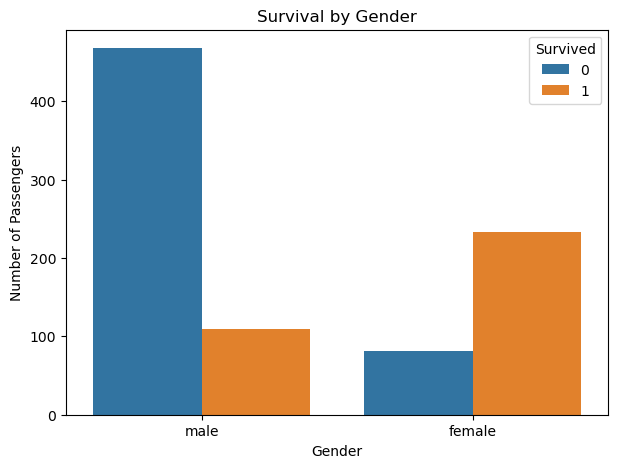

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Sex', hue='Survived')

plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Passengers')

plt.show()

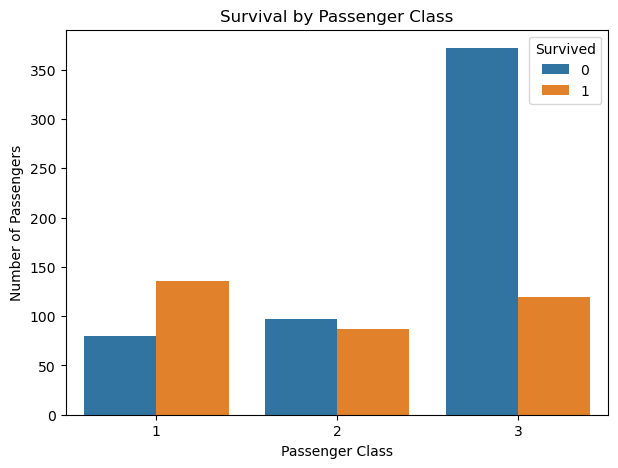

In [14]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Pclass', hue='Survived')

plt.title('Survival by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Number of Passengers')

plt.show()

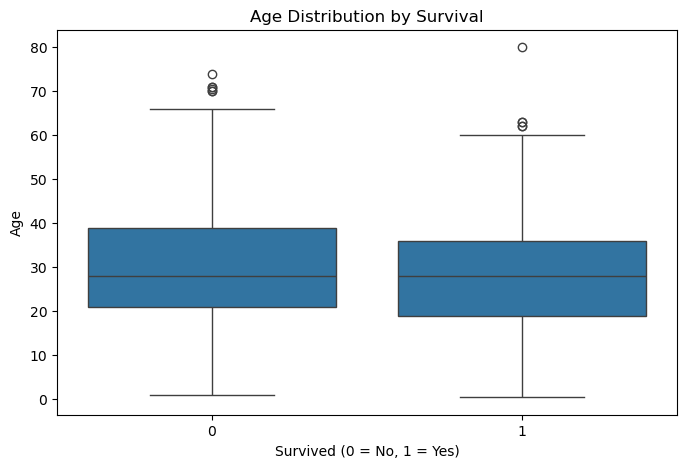

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Survived', y='Age')

plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Age')

plt.show()

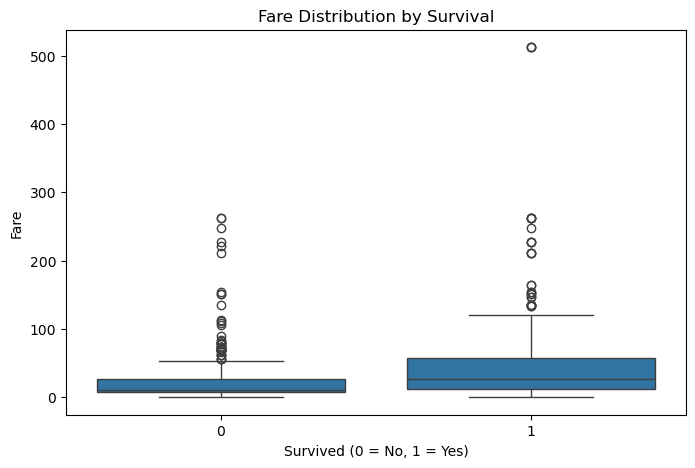

In [16]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Survived', y='Fare')

plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')

plt.show()

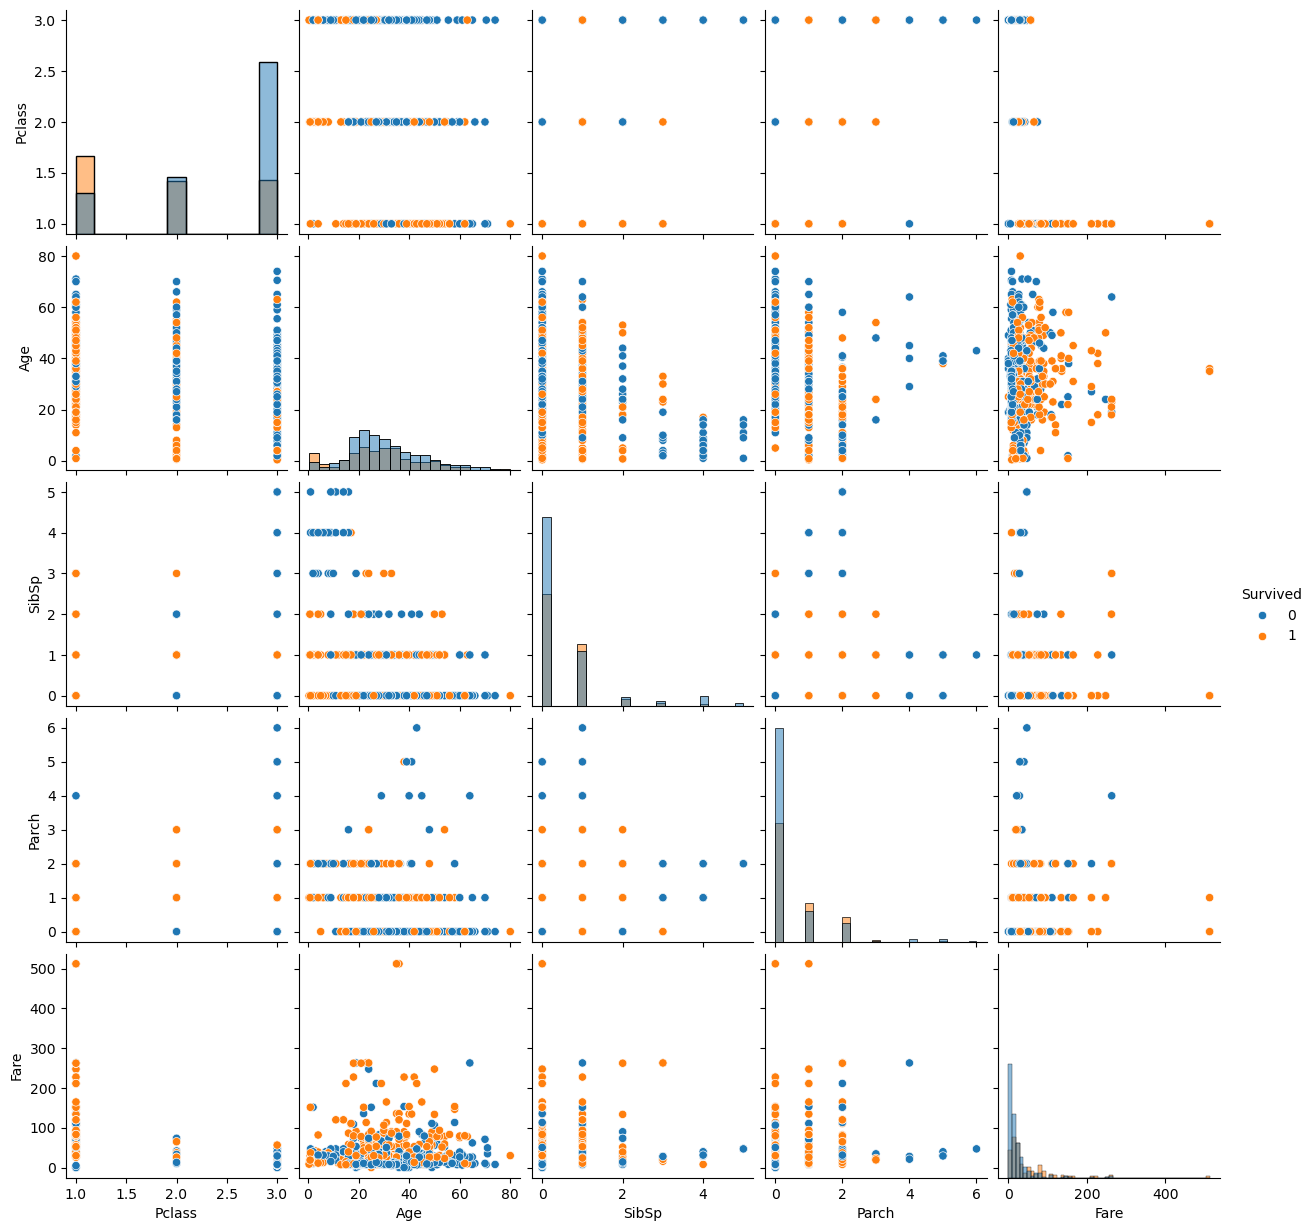

In [17]:
pairplot_data = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()

sns.pairplot(
    pairplot_data,
    hue='Survived',
    diag_kind='hist'
)

plt.show()


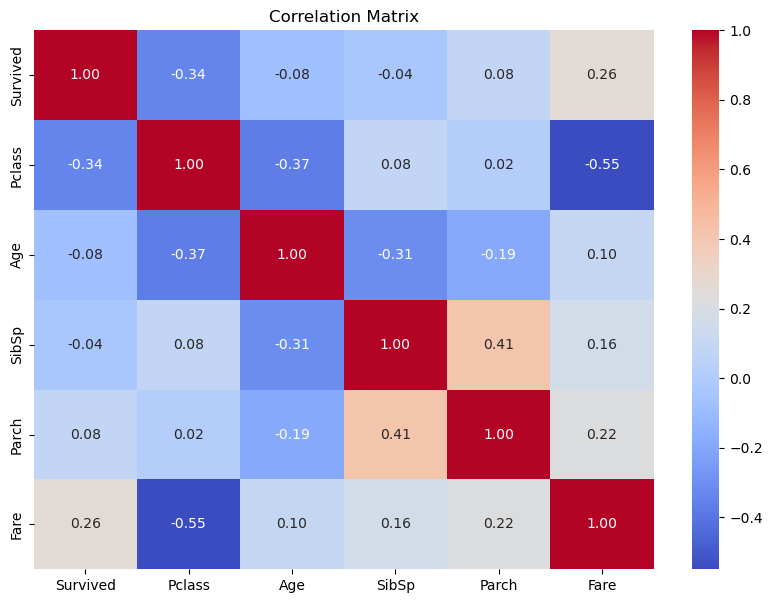

In [18]:
correlation = df[
    ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

In [19]:
print("Skewness of Numerical Features:")
print(df[numeric_features].skew())

Skewness of Numerical Features:
Age      0.389108
Fare     4.787317
SibSp    3.695352
Parch    2.749117
dtype: float64


## EDA Observations

- The dataset contains both numerical and categorical features.
- Missing values are present in columns such as Age, Cabin, and Embarked.
- The numerical features have different distributions.
- Histograms help identify the distribution and skewness of numerical features.
- Boxplots help identify the spread and potential extreme observations.
- Survival distribution shows the number of passengers who survived and did not survive.
- Survival patterns can be compared across gender and passenger class.
- The pairplot helps visualize relationships among numerical features.
- The correlation matrix shows the strength and direction of linear relationships between numerical features.
- Skewness values help identify asymmetric numerical distributions.

## Patterns and Trends

- The dataset contains 891 passengers, and 342 passengers survived while 549 did not survive.
- The survival distribution shows that non-survivors were more numerous than survivors.
- The gender-based survival visualization shows a clear difference in survival between male and female passengers.
- The passenger-class visualization shows different survival distributions across first, second, and third class.
- Fare values are concentrated toward lower values, while a smaller number of passengers paid much higher fares.
- Most passengers had 0 siblings/spouses (`SibSp`) and 0 parents/children (`Parch`), while a smaller number had larger family counts.
- Age values are distributed across a wide range, from approximately 0.42 to 80 years among the available observations.

## Anomalies and Extreme Observations

- The Fare feature contains several high-value observations. The maximum Fare is 512.3292, while the median Fare is only 14.4542, indicating the presence of unusually high fare values.
- The Fare distribution is strongly right-skewed, so the high fare observations are important potential outliers to investigate.
- SibSp has a maximum value of 8, while its median is 0. This indicates that a small number of passengers had considerably larger sibling/spouse counts than most passengers.
- Parch has a maximum value of 6, while its median is 0, indicating that most passengers had no parents/children recorded but a small number had larger values.
- The Age feature ranges from 0.42 to 80 years, showing a wide age range. The boxplot can be used to inspect whether individual ages appear unusually distant from the central distribution.
- Missing values are also an important data-quality issue: Age has 177 missing values and Cabin has 687 missing values.

## Conclusion

Exploratory Data Analysis was performed on the Titanic dataset using Pandas, Matplotlib, and Seaborn.

The analysis included descriptive statistics, mean, median, standard deviation, categorical summaries, histograms, boxplots, survival analysis, pairplot, correlation analysis, and skewness analysis.

The visualizations helped identify distributions, relationships, patterns, and potential extreme observations in the dataset.

EDA provides an understanding of the dataset and helps prepare for further data preprocessing and machine learning tasks.